In [17]:
import os
print(os.getcwd())
print(os.listdir())

/workspace/week02
['.ipynb_checkpoints', 'HW_toyobjects_Gray', 'image_manipulation.ipynb']


In [18]:
# import os
# import numpy as np
# 
# import matplotlib.pyplot as plt

# from docx import Document
# from docx.shared import Inches

# 1. Read Bitmap file

## Loading Data

In [19]:
from pathlib import Path
from PIL import Image

file_path = Path("./HW_toyobjects_Gray")
file_name = "HW_toyobjects_Gray.bmp"

Img_RAW = Image.open(file_path / file_name)

# 2. Display Unique colors in Bitmap file

In [20]:
import numpy as np

np_bitmap = np.array(Img_RAW)
unique_bitmap = np.unique(np_bitmap).size

print(f"Unique colors in bitmap file: {unique_bitmap}")

Unique colors in bitmap file: 6


# 3. Grayscale to Index-color

In [21]:
idx_img = Img_RAW.quantize(colors=unique_bitmap) 
map = idx_img.getpalette() 

# 4. Display Unique Colors in Index-image

In [22]:
np_idx = np.array(idx_img)
unique_idx = np.unique(np_idx).size

print(f"Unique colors in index-image: {unique_idx}")

Unique colors in index-image: 6


# 5. Resize Index-image 180 x 180

In [23]:
idx_img_180 = idx_img.resize((180, 180), resample=Image.Resampling.NEAREST)               # resize, don't forget to use "NEAREST"
# idx_img_180 = idx_img.resize((180, 180)) 
np_idx_180 = np.array(idx_img_180)
unique_idx_180 = np.unique(np_idx_180).size
print(f"Unique colors in 180x180 index-image: {unique_idx_180}")

Unique colors in 180x180 index-image: 6


# 6. Resize Index-image 480 x 480

In [24]:
idx_img_480 = idx_img.resize((480, 480), resample=Image.Resampling.NEAREST)               # resize, don't forget to use "NEAREST"
# idx_img_480 = idx_img.resize((480, 480)) 
np_idx_480 = np.array(idx_img_480)
unique_idx_480 = np.unique(np_idx_480).size
print(f"Unique colors in 480x480 index-image: {unique_idx_480}")

Unique colors in 480x480 index-image: 6


# 7. Save Image in JPG

In [25]:
idx_img_rgb = idx_img.convert("RGB")                                                       # JPEG doesn't support Index-image
idx_img_rgb.save(file_path / "HW_toyobjects_index.jpg", quality=95)
print(f"Saved file in {file_path}")

Saved file in HW_toyobjects_Gray


# 8. Save Image in BMP

In [26]:
idx_img.save(file_path / "HW_toyobjects_index.bmp")
print(f"Saved file in {file_path}")

Saved file in HW_toyobjects_Gray


# 9. Load JPG Image

In [27]:
Img_JPG = Image.open(file_path / "HW_toyobjects_index.jpg")
print(f"Image in mode: {Img_JPG.mode}")

Image in mode: RGB


# 10. Shows Unique Colors of JPEG Image

In [28]:
img_jpg_np = np.array(Img_JPG)
img_jpg_np_flat = img_jpg_np.reshape(-1, 3)                                                     # JPEG 3-dimensions. re-arrange to 2 (H+W, # of channel)
print(f"Unique colors in Img_JPG: {np.unique(img_jpg_np_flat, axis=0).shape[0]}")            # axis=0 treat rows as single unit, axis=1 treat columns

Unique colors in Img_JPG: 76


# 11. Load BMP Image

In [29]:
Img_BMP = Image.open(file_path / "HW_toyobjects_index.bmp")
print(f"Image in mode: {Img_BMP.mode}")

Image in mode: P


# 12. Shows Unique Colors of BMP Image

In [30]:
img_bmp_np = np.array(Img_BMP)
print(f"Unique colors in Img_BMP: {np.unique(img_bmp_np).size}")

Unique colors in Img_BMP: 6


# 13. Display images

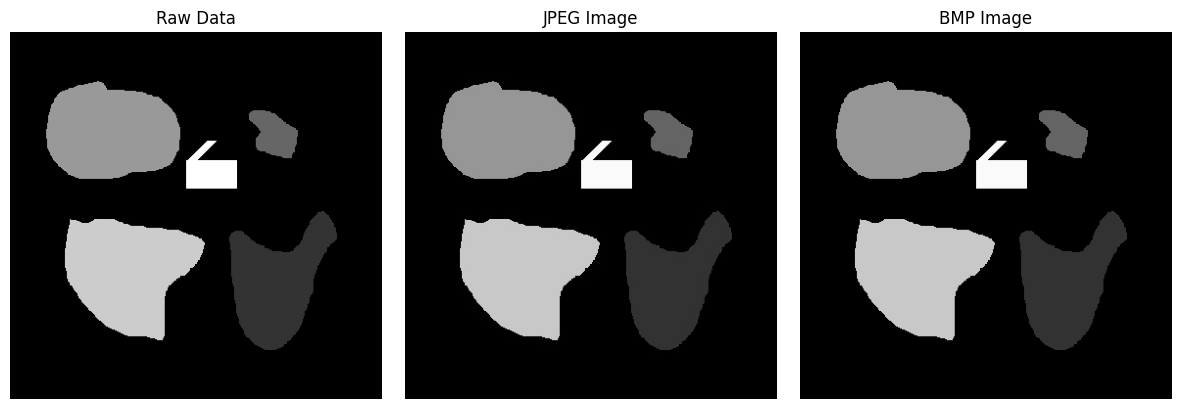

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))  # wider figure

# Grayscale Image
plt.subplot(1, 3, 1)                              # 1 row, 3 columns, position 1
plt.imshow(Img_RAW, cmap="gray")
plt.title("Raw Data")
plt.axis("off")

# JPEG Image
plt.subplot(1, 3, 2)
plt.imshow(Img_JPG)
plt.title("JPEG Image")
plt.axis("off")

# BMP Image
plt.subplot(1, 3, 3)
plt.imshow(Img_BMP)
plt.title("BMP Image")
plt.axis("off")

plt.tight_layout()
plt.show()
